In [1]:
import ncu_report
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np
from pathlib import Path

---

# OMP

In [2]:
wdir = Path("logs/singleImage/OMP/")

In [3]:
staticData = pd.read_csv(wdir/"staticTimes.csv", sep=' ', names=["threads", "N", "real", "user", "sys"], header=None)
dynamicData = pd.read_csv(wdir/"dynamicTimes.csv", sep=' ', names=["threads", "N", "real", "user", "sys"], header=None)
staticData

,threads,N,real,user,sys
0,2,512,0.014,0.023,0.001
1,2,512,0.015,0.023,0.003
2,2,512,0.013,0.022,0.002
3,2,512,0.014,0.023,0.001
4,2,512,0.014,0.024,0.000
...,...,...,...,...,...
2095,8,16384,10.963,79.128,0.434
2096,8,16384,10.946,79.567,0.437
2097,8,16384,10.931,79.041,0.443
2098,8,16384,10.973,79.210,0.405


In [4]:
cmap = ['k', "#E69F00", "#D55E00", "#56B4E9", "#0072B2", "#009E73", ]

firstC = cmap[:3]
secondC = cmap[3:]

firstKwargs = {"y":"mean", "yerr":"std", "capsize":2, "fontsize":12}
secondKwargs = {"y":"mean", "yerr":"std", "ls":"--", "capsize":2, "alpha":.5, "fontsize":12, "legend":False}

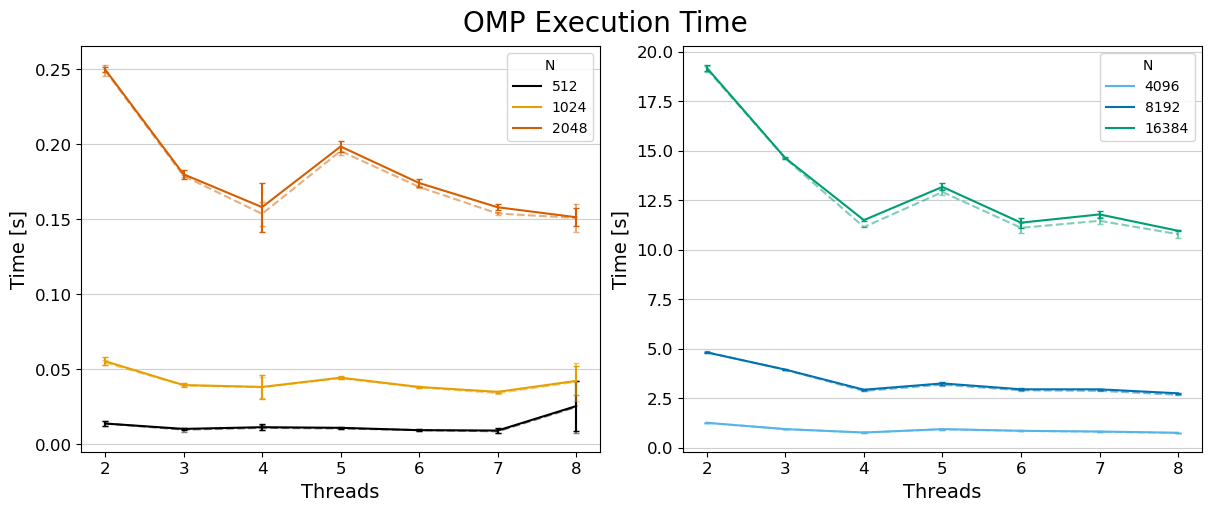

In [5]:
staticMeanStd = staticData.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack()
dynamicMeanStd = dynamicData.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack()

fig, ax = plt.subplots(1,2,figsize=(12,5), layout="constrained")
fig.suptitle("OMP Execution Time", fontsize=20)

ax[0].set_prop_cycle(cycler(color=firstC))
staticMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**firstKwargs, ax=ax[0])
dynamicMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**secondKwargs, ax=ax[0])

ax[1].set_prop_cycle(cycler(color=secondC))
staticMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**firstKwargs, ax=ax[1])
dynamicMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**secondKwargs, ax=ax[1])

for Ax in ax:
    Ax.grid(axis='y', alpha=.6)
    Ax.set_xlabel("Threads", fontsize=14)
    Ax.set_ylabel("Time [s]", fontsize=14)

# plt.savefig("OMPExec.pdf")
plt.show()

---

In [6]:
statFunc = pd.read_csv(wdir/"centerRevFftTGaussIfftStatic.csv", sep=' ', names=["threads", "N", "Center", "Bit-rev", "FFT", "T", "Gauss", "IFFT"], header=None)
dynFunc = pd.read_csv(wdir/"centerRevFftTGaussIfftDynamic.csv", sep=' ', names=["threads", "N", "Center", "Bit-rev", "FFT", "T", "Gauss", "IFFT"], header=None)

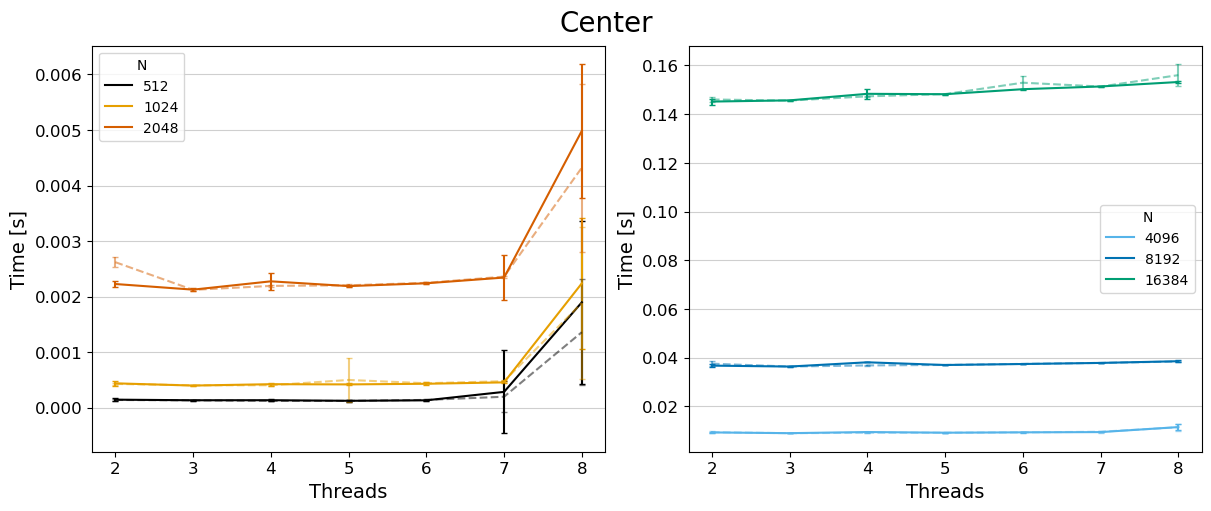

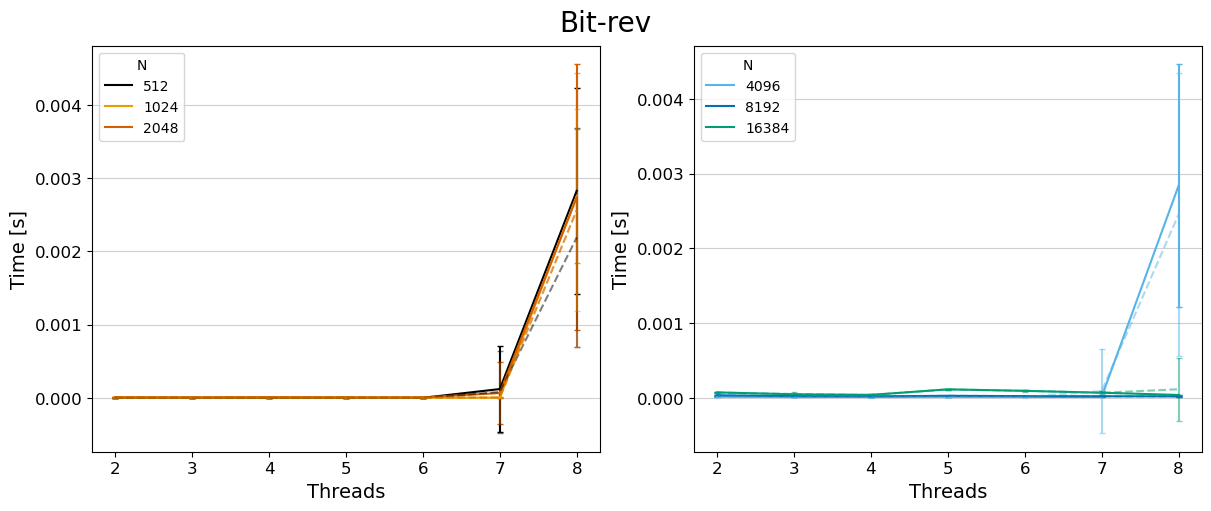

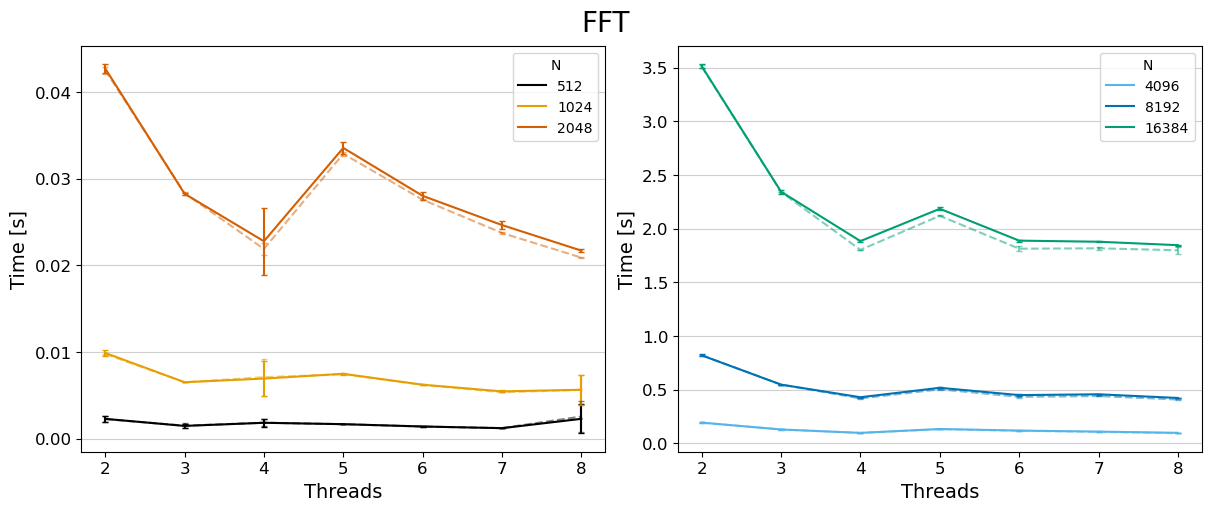

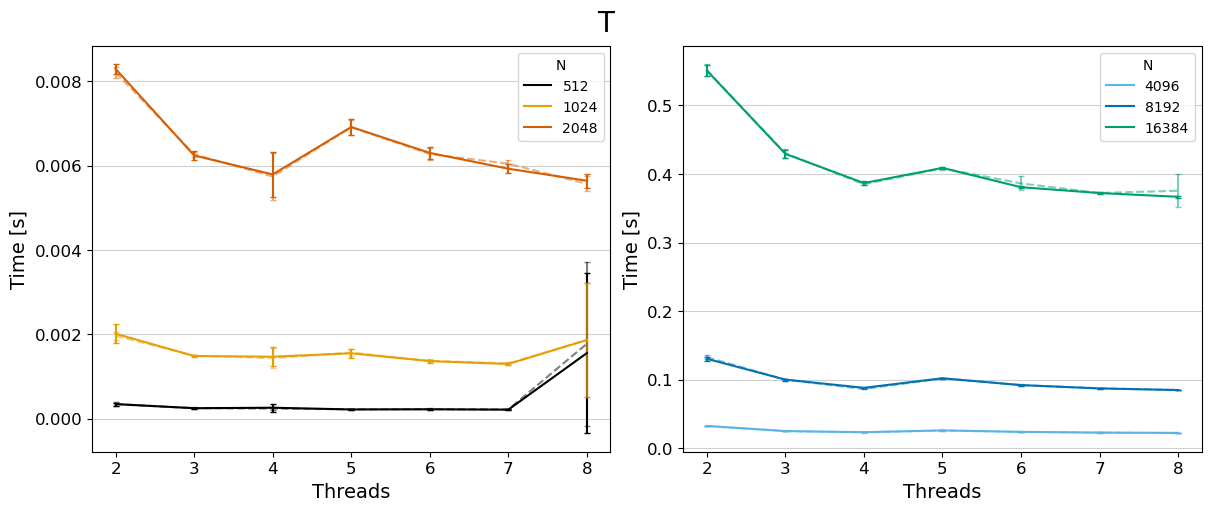

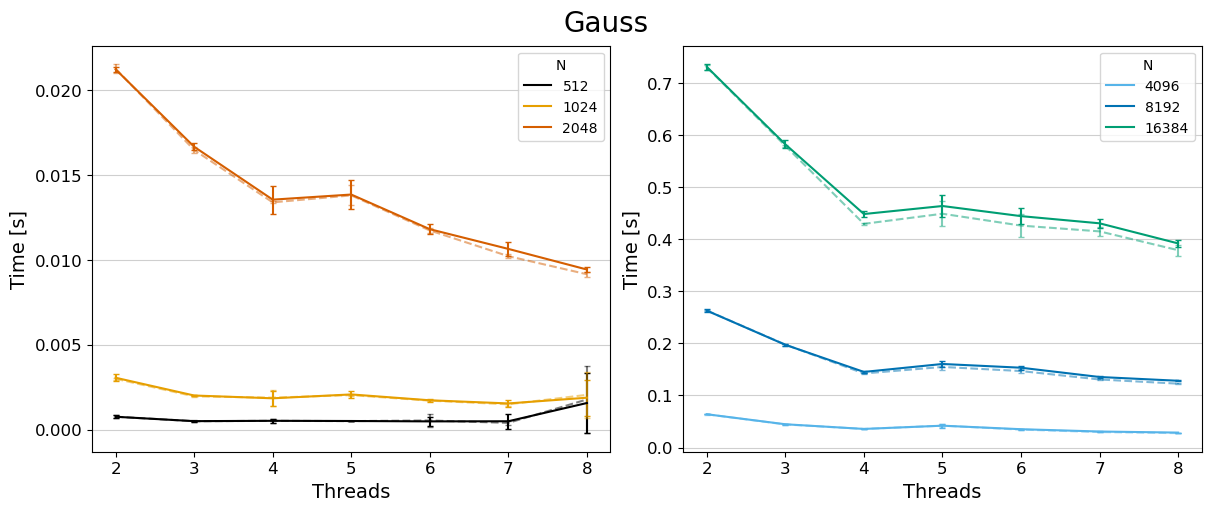

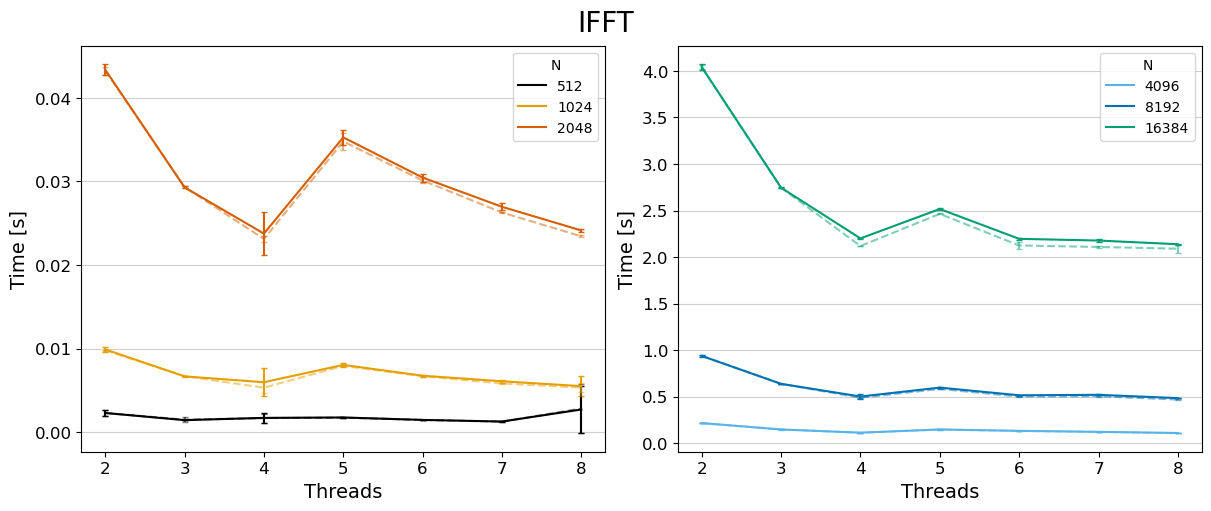

In [7]:
for name in statFunc.columns[2:]:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
    fig.suptitle(name, fontsize=20)
    
    statFuncMeanStd = statFunc.groupby(["threads", "N"]).agg(["mean", "std"])[name].unstack()
    dynFuncMeanStd = dynFunc.groupby(["threads", "N"]).agg(["mean", "std"])[name].unstack()
    
    ax[0].set_prop_cycle(cycler(color=firstC))
    statFuncMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**firstKwargs, ax=ax[0])
    dynFuncMeanStd.loc[:, (["mean", "std"], [512, 1024, 2048])].plot(**secondKwargs, ax=ax[0])
    
    ax[1].set_prop_cycle(cycler(color=secondC))
    statFuncMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**firstKwargs, ax=ax[1])
    dynFuncMeanStd.loc[:, (["mean", "std"], [4096, 8192, 16384])].plot(**secondKwargs, ax=ax[1])

    for Ax in ax:
        Ax.grid(axis='y', alpha=.6)
        Ax.set_xlabel("Threads", fontsize=14)
        Ax.set_ylabel("Time [s]", fontsize=14)


plt.show()

# CUDA

In [8]:
wdir = Path("logs/singleImage/cuda/")

In [9]:
cuData = pd.read_csv(wdir/"times.csv", sep=' ', names=["N", "real", "user", "sys"], header=None)
cuMeanStd = cuData.groupby("N").agg(["mean", "std"])["real"].unstack()
cuMeanStd

      N    
mean  512      0.186260
      1024     0.193840
      2048     0.213230
      4096     0.302630
      8192     0.676520
      16384    2.212660
std   512      0.026865
      1024     0.006846
      2048     0.006796
      4096     0.004629
      8192     0.004164
      16384    0.004870
dtype: float64

# Comparison

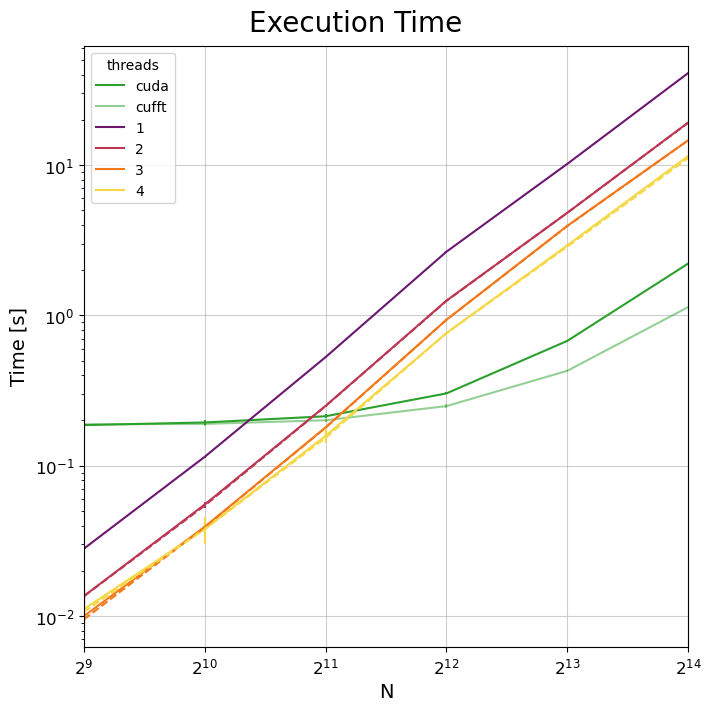

In [10]:
wdir = Path("logs/singleImage/")
pdNames = ["N", "real", "user", "sys"]
colors = plt.get_cmap("inferno")(np.linspace(0.3, 0.9, 4))

fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
fig.suptitle("Execution Time", fontsize=20)
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.set_xlim(512, 16384)

cmap = {
        "1":{"color":colors[0]},
        "cuda":{"color":"tab:green"},
        "cufft":{"color":"tab:green", "alpha":0.5},
        "threads":{"color":colors[1:]}
       }

for file in wdir.glob("**/times.csv"):
    data = pd.read_csv(file, sep=' ', names=pdNames, header=None)
    data.groupby("N").agg(["mean", "std"])["real"].plot(y="mean", yerr="std", xticks=data["N"].unique(), **cmap[file.parent.name], label=file.parent.name, fontsize=12, ax=ax)

for file, kwarg in {"OMP/staticTimes.csv": {"ls": "-"}, "OMP/dynamicTimes.csv": {"ls": "--", "legend": False}}.items():
    data = pd.read_csv(wdir/file, sep=' ', names=["threads"] + pdNames, header=None)
    data = data[data["threads"]<=4]
    data.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack(level=0).plot(y="mean", yerr="std", **cmap["threads"], **kwarg, ax=ax)
    
ax.grid(alpha=.6)
ax.set_xlabel("N", fontsize=14)
ax.set_ylabel("Time [s]", fontsize=14)

# plt.savefig("exec.pdf")
plt.show()

---

# 100 Images

In [11]:
wdir = Path("logs/multImages/")
pdNames = ["N", "real", "user", "sys"]

for file in list((wdir.parent/"tesla").glob("*Streams.csv")) + list(wdir.glob("*.csv")):
    data = pd.read_csv(file, sep=' ', names=pdNames, header=None)
    print(file, data["real"].agg(["mean", "std"]).values)

logs/tesla/1Streams.csv [12.41368     0.11940593]
logs/tesla/2Streams.csv [6.75749    0.27346104]
logs/multImages/3Streams.csv [9.77686    0.03354118]
logs/multImages/2Streams.csv [9.75727    0.03576095]
logs/multImages/1Streams.csv [10.71332     0.03444946]
logs/multImages/ser.csv [230.89344      0.33060703]
logs/multImages/omp.csv [69.8962      0.53227022]
logs/multImages/omp4Cores.csv [73.42436364  0.22037063]
logs/multImages/cufft1Stream.csv [4.89473    0.04784083]
logs/multImages/cufft2Streams.csv [3.85517    0.06509854]


# NCU

In [12]:
times = {}
for N in [2**i for i in range(9, 15)]:
    times[N] = []
    context = ncu_report.load_report(f"logs/singleImage/cuda/{N}.ncu-rep")
    ncuRange = context[0]
    
    actDict = {}
    for action in ncuRange:
        name = action.name()
        time = action.metric_by_name('gpu__time_duration.avg').value() * 1e-6
        if actDict.get(name): actDict[name].append(time)
        else: actDict[name] = [time]
        times[N].append(time)
    print(N)
    for key, item in actDict.items(): print(f"{key} -- # kernels: {len(item)} -- gpu time: {np.mean(item)} +- {np.std(item)} ms")
    print("Total Time:", sum(times[N]), "ms\n")
for key, value in times.items(): times[key] = sum(value)

512
centerKer -- # kernels: 2 -- gpu time: 0.015248 +- 0.0019679999999999993 ms
revBitShOrdKer -- # kernels: 2 -- gpu time: 0.026912 +- 9.599999999999886e-05 ms
coolSubKer -- # kernels: 18 -- gpu time: 0.014839111111111112 +- 0.0007515123188824645 ms
transposeKer -- # kernels: 2 -- gpu time: 0.025664 +- 0.00012799999999999964 ms
gaussKer -- # kernels: 1 -- gpu time: 0.01392 +- 0.0 ms
revBitOrdKer -- # kernels: 2 -- gpu time: 0.035295999999999994 +- 0.00012799999999999964 ms
busLoocKer -- # kernels: 18 -- gpu time: 0.014824888888888887 +- 0.0007719753082471029 ms
sharedTransposeKer -- # kernels: 2 -- gpu time: 0.015184 +- 1.600000000000039e-05 ms
mulKer -- # kernels: 1 -- gpu time: 0.014272 +- 0.0 ms
Total Time: 0.798752 ms

1024
centerKer -- # kernels: 2 -- gpu time: 0.06767999999999999 +- 0.002239999999999999 ms
revBitShOrdKer -- # kernels: 2 -- gpu time: 0.1132 +- 1.6000000000002124e-05 ms
coolSubKer -- # kernels: 20 -- gpu time: 0.06760479999999999 +- 0.0006842521172784197 ms
transp

## "Ghost Time"

In [13]:
## ms
malloc = pd.read_csv("logs/singleImage/cuda/mallocMemcpyAsync.csv", sep=' ', header=None, names=["N","Malloc", "Memcpy"]).groupby("N").agg(["mean", "std"]) * 2
malloc["totKerTime"] = times
malloc["cudaTotMean"] = cuMeanStd["mean"] * 1e3
malloc["cudaTotStd"] = cuMeanStd["std"] * 1e3
malloc["sum"] = malloc["Malloc", "mean"] + malloc["Memcpy", "mean"] + malloc["totKerTime"]
malloc["std"] = malloc["Malloc", "std"] + malloc["Memcpy", "std"]
malloc["ghostTime"] = malloc["cudaTotMean"] - malloc["sum"]
display(malloc)

Malloc                Memcpy             totKerTime cudaTotMean  \
            mean       std        mean       std                            
N                                                                           
512     6.606423  0.398437    0.351294  0.006473     0.798752      186.26   
1024    6.640986  0.395270    1.338210  0.013028     3.777728      193.84   
2048    6.635112  0.384796    5.241482  0.017933    16.806720      213.23   
4096    6.788225  0.395521   20.852532  0.034328    72.052832      302.63   
8192    7.449498  0.372875   83.256328  0.022721   305.350784      676.52   
16384  10.167345  0.486642  333.293660  1.545610  1293.510560     2212.66   

      cudaTotStd          sum       std   ghostTime  
                                                     
N                                                    
512    26.864651     7.756469  0.404910  178.503531  
1024    6.845658    11.756924  0.408298  182.083076  
2048    6.795505    28.683315  0.402729  184.546685  
4096    4.628971    99.693589  0.429849  202.936411  
8192    4.164496   396.056610  0.395596  280.463390  
16384   4.870484  1636.971565  2.032251  575.688435

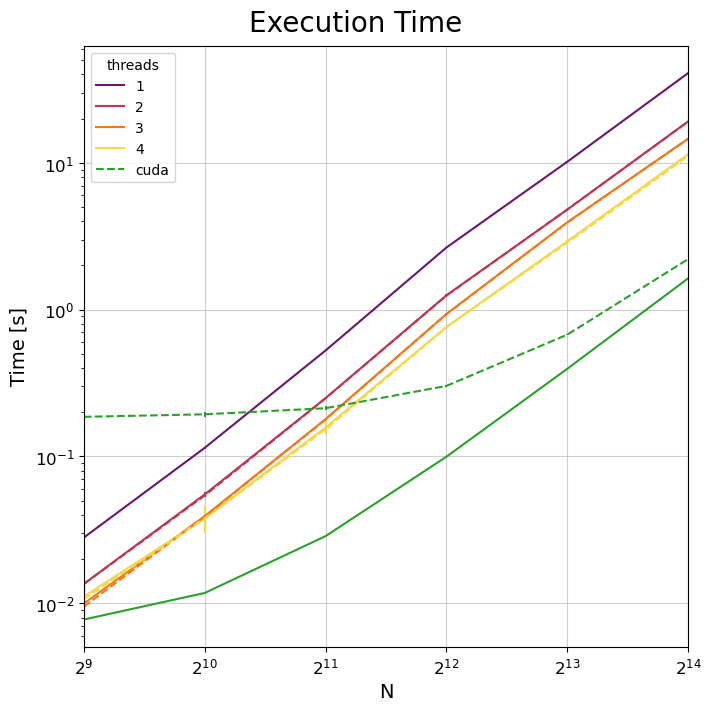

In [14]:
wdir = Path("logs/singleImage/")
pdNames = ["N", "real", "user", "sys"]
colors = plt.get_cmap("inferno")(np.linspace(0.3, 0.9, 4))

fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
fig.suptitle("Execution Time", fontsize=20)
ax.set_yscale("log")
ax.set_xscale("log", base=2)
ax.set_xlim(512, 16384)

cmap = {
        "1":{"color":colors[0]},
        "cuda":{"color":"tab:green", "alpha":0.5},
        "cufft":{"color":"tab:green"},
        "threads":{"color":colors[1:]}
       }

data = pd.read_csv("logs/singleImage/1/times.csv", sep=' ', names=pdNames, header=None)
data.groupby("N").agg(["mean", "std"])["real"].plot(y="mean", yerr="std", xticks=data["N"].unique(), color=colors[0], label="1", fontsize=12, ax=ax)

for file, kwarg in {"OMP/staticTimes.csv": {"ls": "-"}, "OMP/dynamicTimes.csv": {"ls": "--", "legend": False}}.items():
    data = pd.read_csv(wdir/file, sep=' ', names=["threads"] + pdNames, header=None)
    data = data[data["threads"]<=4]
    data.groupby(["threads", "N"]).agg(["mean", "std"])["real"].unstack(level=0).plot(y="mean", yerr="std", **cmap["threads"], **kwarg, ax=ax)


pd.read_csv("logs/singleImage/cuda/times.csv", sep=' ', names=pdNames, header=None).groupby("N").agg(["mean", "std"])["real"].plot(y="mean", yerr="std", xticks=data["N"].unique(), color="tab:green", ls="--", label="cuda", fontsize=12, ax=ax)

malloc["threads", "sum"] = malloc["sum"] * 1e-3
malloc["threads", "sum"].plot(color="tab:green", fontsize=12, ax=ax)

ax.grid(alpha=.6)
ax.set_xlabel("N", fontsize=14)
ax.set_ylabel("Time [s]", fontsize=14)

# plt.savefig("corrected.pdf")
plt.show()